In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import tarfile
import urllib.request
from sklearn.metrics import confusion_matrix, precision_score, recall_score

In [2]:
# Download and load CIFAR-10
url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
file_name = "/content/cifar-10-python.tar.gz"
folder = "/content/cifar-10-batches-py"

if not os.path.exists(folder):
    urllib.request.urlretrieve(url, file_name)
    with tarfile.open(file_name, "r:gz") as tar:
        tar.extractall("/content")

def load_batch(file):
    with open(file, "rb") as f:
        data = pickle.load(f, encoding="bytes")
    return data[b"data"], np.array(data[b"labels"])

X_train = []
y_train = []

for i in range(1, 6):
    X, y = load_batch(f"{folder}/data_batch_{i}")
    X_train.append(X)
    y_train.append(y)

X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)

X_test, y_test = load_batch(f"{folder}/test_batch")

classes = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

/tmp/ipykernel_1033/196295259.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content")


Training data: (50000, 3072)
Testing data: (10000, 3072)


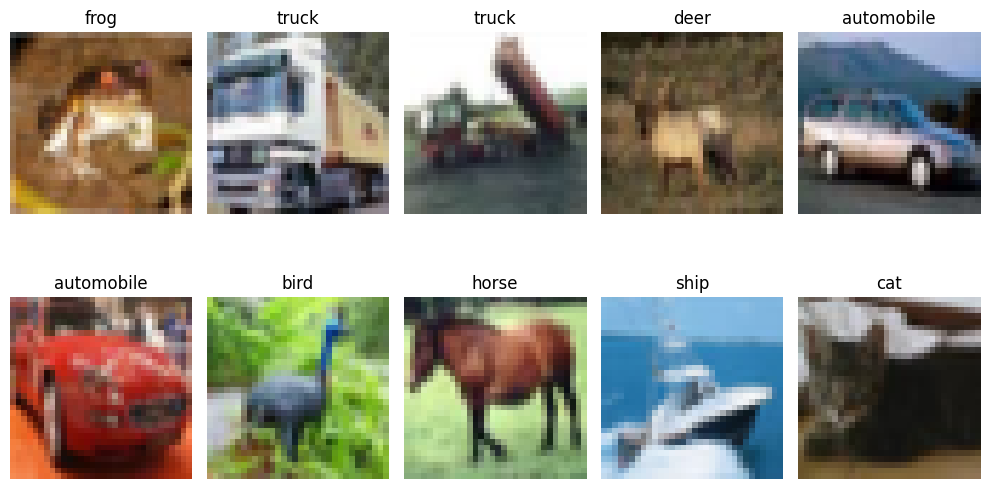

In [3]:
plt.figure(figsize=(10, 6))

for i in range(10):
    image = X_train[i].reshape(3, 32, 32).transpose(1, 2, 0)
    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(classes[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:

#Preprocessing
np.random.seed(42)

train_size = 5000
test_size = 1000

train_indices = np.random.choice(len(X_train), train_size, replace=False)
test_indices = np.random.choice(len(X_test), test_size, replace=False)

Xtr = X_train[train_indices].astype(float) / 255.0
ytr = y_train[train_indices]

Xte = X_test[test_indices].astype(float) / 255.0
yte = y_test[test_indices]

print("Training samples used:", len(Xtr))
print("Testing samples used:", len(Xte))

Training samples used: 5000
Testing samples used: 1000


In [5]:
#Distance functions
def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def manhattan(a, b):
    return np.sum(np.abs(a - b))

def minkowski(a, b, p=3):
    return np.sum(np.abs(a - b) ** p) ** (1 / p)

def cosine(a, b):
    denominator = np.linalg.norm(a) * np.linalg.norm(b)
    if denominator == 0:
        return 1
    return 1 - (np.dot(a, b) / denominator)

def hamming(a, b):
    return np.mean(a != b)

In [6]:
#KNN from scratch
def distance(a, b, metric):
    if metric == "euclidean":
        return euclidean(a, b)
    elif metric == "manhattan":
        return manhattan(a, b)
    elif metric == "minkowski":
        return minkowski(a, b)
    elif metric == "cosine":
        return cosine(a, b)
    elif metric == "hamming":
        return hamming(a, b)

def knn_predict(X_train, y_train, X_test, k, metric):
    predictions = []

    for test_point in X_test:
        distances = []

        for i in range(len(X_train)):
            d = distance(test_point, X_train[i], metric)
            distances.append((d, y_train[i]))

        distances.sort(key=lambda x: x[0])

        nearest = distances[:k]
        labels = [x[1] for x in nearest]

        predictions.append(max(set(labels), key=labels.count))

    return np.array(predictions)

In [7]:
#Required experiments
K_values = [3, 4, 9, 20, 47]
metrics = ["euclidean", "manhattan", "minkowski", "cosine", "hamming"]

results = []

for metric in metrics:
    for k in K_values:
        print("Running:", metric, "K =", k)

        y_pred = knn_predict(Xtr, ytr, Xte, k, metric)
        accuracy = np.mean(y_pred == yte)

        results.append([metric, k, accuracy])

print(results)

Running: euclidean K = 3
Running: euclidean K = 4
Running: euclidean K = 9
Running: euclidean K = 20
Running: euclidean K = 47
Running: manhattan K = 3
Running: manhattan K = 4
Running: manhattan K = 9
Running: manhattan K = 20
Running: manhattan K = 47
Running: minkowski K = 3
Running: minkowski K = 4
Running: minkowski K = 9
Running: minkowski K = 20
Running: minkowski K = 47
Running: cosine K = 3
Running: cosine K = 4
Running: cosine K = 9
Running: cosine K = 20
Running: cosine K = 47
Running: hamming K = 3
Running: hamming K = 4
Running: hamming K = 9
Running: hamming K = 20
Running: hamming K = 47
[['euclidean', 3, np.float64(0.262)], ['euclidean', 4, np.float64(0.264)], ['euclidean', 9, np.float64(0.271)], ['euclidean', 20, np.float64(0.268)], ['euclidean', 47, np.float64(0.267)], ['manhattan', 3, np.float64(0.287)], ['manhattan', 4, np.float64(0.294)], ['manhattan', 9, np.float64(0.304)], ['manhattan', 20, np.float64(0.292)], ['manhattan', 47, np.float64(0.29)], ['minkowski', 3,

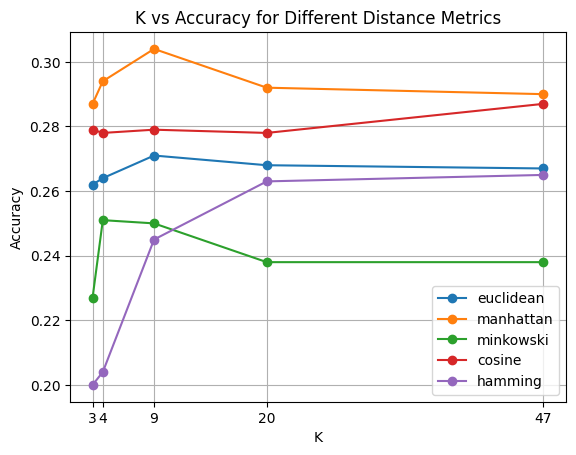

In [8]:
#Plot K vs Accuracy
for metric in metrics:
    k_list = []
    acc_list = []

    for row in results:
        if row[0] == metric:
            k_list.append(row[1])
            acc_list.append(row[2])

    plt.plot(k_list, acc_list, marker="o", label=metric)

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy for Different Distance Metrics")
plt.xticks(K_values)
plt.legend()
plt.grid()
plt.show()

In [9]:
#Best K and distance metric
best = max(results, key=lambda x: x[2])

best_metric = best[0]
best_k = best[1]
best_accuracy = best[2]

print("Best distance metric:", best_metric)
print("Best K:", best_k)
print("Best accuracy:", best_accuracy)

Best distance metric: manhattan
Best K: 9
Best accuracy: 0.304


In [10]:
#Confusion matrix, precision and recall
best_pred = knn_predict(Xtr, ytr, Xte, best_k, best_metric)

cm = confusion_matrix(yte, best_pred)

print("Confusion Matrix:")
print(cm)

precision = precision_score(yte, best_pred, average="macro", zero_division=0)
recall = recall_score(yte, best_pred, average="macro", zero_division=0)

print("Precision:", precision)
print("Recall:", recall)

Confusion Matrix:
[[45  0 13  0  8  0  1  1 22  0]
 [17 10 16  6 22  1 13  4 22  4]
 [21  0 46  2 35  4  4  0  5  1]
 [11  0 22 22 21  9  7  0  9  2]
 [ 8  0 33  0 53  2  3  2  5  0]
 [ 9  0 25 12 22 20 11  0  3  0]
 [ 3  1 25  5 32  1 23  1  2  0]
 [ 5  1 13  4 32  4  0 18  6  3]
 [20  0  2  0  5  2  4  1 52  1]
 [14  7 12  4 14  1  8  3 22 15]]
Precision: 0.3953499467139522
Recall: 0.3090772997559636


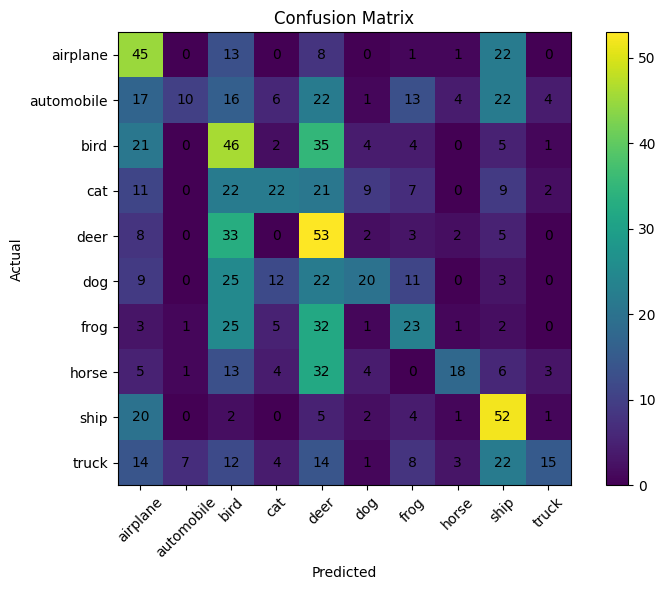

In [11]:
plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.colorbar()

plt.xticks(range(10), classes, rotation=45)
plt.yticks(range(10), classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()
